# UR5 Robot Kinematics: Complete Dual Quaternion Pipeline

## Full implementation of:
- **Screw Theory** — geometric joint axis representation
- **Product of Exponentials (PoE)** — forward kinematics
- **Dual Quaternions** — singularity-free pose representation
- **Analytical DQ Jacobian** — velocity and IK
- **Numerical IK** — damped least squares with joint limits
- **ScLERP** — screw-linear trajectory interpolation
- **Neural Network IK** — DQ input, joint angle output
- **Hybrid Solver** — NN warm start + numerical refinement

## Robot: Universal Robots UR5
- 6 Revolute joints (6R)
- Reach: ~850 mm, Payload: 5 kg
- All units: **metres** and **radians**

---
**Reference:** Modern Robotics — Lynch & Park (2017)


## Cell 1 — Install and Import Dependencies

We use:
- `numpy` — all linear algebra and array operations
- `scipy` — matrix exponential via `expm` (used for verification only)
- `tensorflow` / `keras` — neural network for learned IK
- `matplotlib` — plotting errors and trajectories

We do **NOT** use the `dual_quaternions` library — we implement everything
from scratch so the maths is fully transparent and correct.


In [37]:
# Install required packages
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                       'numpy', 'matplotlib', '-q'])



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


0

In [38]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

np.set_printoptions(precision=6, suppress=True)
print(f'NumPy  : {np.__version__}')
print(f'TF     : {tf.__version__}')
print('All imports successful.')

NumPy  : 2.4.6
TF     : 2.21.0
All imports successful.


---
## PART 1 — UR5 GEOMETRY: DH PARAMETERS

The UR5 uses **Modified DH (Craig convention)**.
Each row describes the transform from frame i-1 to frame i:

| Joint | a (m)     | α (rad)  | d (m)    | θ offset |
|-------|-----------|----------|----------|----------|
| 1     | 0         | 0        | 0.1273   | 0        |
| 2     | 0         | -π/2     | 0        | 0        |
| 3     | -0.4250   | 0        | 0        | 0        |
| 4     | -0.3922   | 0        | 0.1091   | 0        |
| 5     | 0         | +π/2     | 0.0946   | 0        |
| 6     | 0         | -π/2     | 0.0823   | 0        |

Where:
- **a** = link length along x-axis
- **α** = link twist about x-axis  
- **d** = link offset along z-axis
- **θ** = joint angle about z-axis (our variable)


In [39]:
# ============================================================
# UR5 DH Parameters (Modified DH / Craig Convention)
# All distances in metres, angles in radians
# ============================================================

# Link lengths along x-axis (a_i-1)
DH_a     = np.array([0.0,      0.0,      -0.42500, -0.39225,  0.0,      0.0    ])

# Link twists about x-axis (alpha_i-1) in radians
DH_alpha = np.array([0.0,     -np.pi/2,   0.0,      0.0,      np.pi/2, -np.pi/2])

# Link offsets along z-axis (d_i) in metres
DH_d     = np.array([0.1273,   0.0,        0.0,      0.10915,  0.09465,  0.0823 ])

# Zero-configuration joint angles (theta offsets)
DH_theta = np.zeros(6)

print('UR5 DH Parameters:')
print(f'{"Joint":>6}  {"a (m)":>10}  {"alpha (rad)":>12}  {"d (m)":>10}  {"theta0":>8}')
print('-' * 55)
for i in range(6):
    print(f'  {i+1:>4}  {DH_a[i]:>10.5f}  {DH_alpha[i]:>12.6f}  {DH_d[i]:>10.5f}  {DH_theta[i]:>8.4f}')

UR5 DH Parameters:
 Joint       a (m)   alpha (rad)       d (m)    theta0
-------------------------------------------------------
     1     0.00000      0.000000     0.12730    0.0000
     2     0.00000     -1.570796     0.00000    0.0000
     3    -0.42500      0.000000     0.00000    0.0000
     4    -0.39225      0.000000     0.10915    0.0000
     5     0.00000      1.570796     0.09465    0.0000
     6     0.00000     -1.570796     0.08230    0.0000


---
## PART 2 — HOME CONFIGURATION M

**M is the end-effector pose (4×4 homogeneous transform) when ALL joint angles = 0.**

It is computed by chaining all DH transforms at θᵢ = 0:

$$M = T_{01}(0) \cdot T_{12}(0) \cdot T_{23}(0) \cdot T_{34}(0) \cdot T_{45}(0) \cdot T_{56}(0)$$

**Why M is NOT the identity matrix:**
Even with no joint motion, the robot's physical geometry places the 
end-effector at a specific location and orientation in the base frame.

**Key insight:** M and the screw axes Sᵢ come from the same geometry 
but describe different things:
- **Sᵢ** → HOW joint i moves the robot (axis direction + moment arm)
- **M**  → WHERE the end-effector sits before any joint moves


In [40]:
# ============================================================
# DH Transform Matrix (Modified DH / Craig Convention)
# ============================================================
def dh_matrix(a, alpha, d, theta):
    """
    Compute 4x4 homogeneous transform from Modified DH parameters.
    
    Parameters
    ----------
    a     : float  Link length (metres)
    alpha : float  Link twist (radians)
    d     : float  Link offset (metres)
    theta : float  Joint angle (radians)
    
    Returns
    -------
    T : (4,4) ndarray  Homogeneous transform matrix
    """
    ct, st = np.cos(theta), np.sin(theta)
    ca, sa = np.cos(alpha), np.sin(alpha)
    return np.array([
        [ct,    -st,     0,    a   ],
        [st*ca,  ct*ca, -sa,  -d*sa],
        [st*sa,  ct*sa,  ca,   d*ca],
        [0,      0,      0,    1   ]
    ])


# ============================================================
# Compute M: chain all DH transforms at theta = 0
# ============================================================
M = np.eye(4)
for i in range(6):
    M = M @ dh_matrix(DH_a[i], DH_alpha[i], DH_d[i], 0.0)
M[np.abs(M) < 1e-10] = 0.0

print('Home Configuration M (end-effector pose at all joints = 0):')
print(M)
print()
print(f'End-effector position at zero config:')
print(f'  x = {M[0,3]:.6f} m  ({M[0,3]*1000:.2f} mm)')
print(f'  y = {M[1,3]:.6f} m  ({M[1,3]*1000:.2f} mm)')
print(f'  z = {M[2,3]:.6f} m  ({M[2,3]*1000:.2f} mm)')
print()
print('End-effector rotation matrix at zero config:')
print(M[:3,:3])

Home Configuration M (end-effector pose at all joints = 0):
[[ 1.       0.       0.      -0.81725]
 [ 0.       0.       1.       0.19145]
 [ 0.      -1.       0.       0.22195]
 [ 0.       0.       0.       1.     ]]

End-effector position at zero config:
  x = -0.817250 m  (-817.25 mm)
  y = 0.191450 m  (191.45 mm)
  z = 0.221950 m  (221.95 mm)

End-effector rotation matrix at zero config:
[[ 1.  0.  0.]
 [ 0.  0.  1.]
 [ 0. -1.  0.]]


---
## PART 3 — SCREW AXES IN SPACE FRAME

A **screw axis** Sᵢ is a 6-vector:
$$S_i = \begin{bmatrix} \hat{\omega}_i \\ v_i \end{bmatrix} \in \mathbb{R}^6$$

Where:
- $\hat{\omega}_i$ = unit rotation axis direction of joint i (in world/space frame, at zero config)
- $v_i = -\hat{\omega}_i \times q_i$ = linear velocity component (moment arm)
- $q_i$ = any point ON joint i's rotation axis (in world frame, at zero config)

### Joint Axis Directions at Zero Configuration
Tracked by accumulating the α rotations through the DH chain:

| Joint | Axis direction (world frame) | Why |
|-------|------------------------------|-----|
| 1     | [0, 0, 1]  | Base rotates about world Z |
| 2     | [0, 1, 0]  | α₁ = -π/2 flips Z→Y |
| 3     | [0, 1, 0]  | α₂ = 0, unchanged |
| 4     | [0, 1, 0]  | α₃ = 0, unchanged |
| 5     | [0, 0, -1] | α₄ = +π/2 flips Y→-Z |
| 6     | [0, 1, 0]  | α₅ = -π/2 flips back |

### Joint Origin Points at Zero Configuration
Traced by following link translations through the chain:
- d values go along CURRENT frame Z direction (in world)
- a values go along CURRENT frame X direction (in world)


In [41]:
# ============================================================
# Joint Axis Directions (omega_hat) at Zero Configuration
# These are the unit vectors that each joint rotates about,
# expressed in the WORLD (space) frame.
# ============================================================

W = np.array([
    [0.,  0.,  1.],   # Joint 1: rotates about world Z
    [0.,  1.,  0.],   # Joint 2: rotates about world Y (alpha1=-pi/2 rotated Z->Y)
    [0.,  1.,  0.],   # Joint 3: still world Y (alpha2=0, unchanged)
    [0.,  1.,  0.],   # Joint 4: still world Y (alpha3=0, unchanged)
    [0.,  0., -1.],   # Joint 5: world -Z (alpha4=+pi/2 rotated Y->-Z ... see note) [0.,  0., -1.],
    [0.,  1.,  0.],   # Joint 6: world Y  (alpha5=-pi/2 flipped back)
])

# Verify all axes are unit vectors
for i, w in enumerate(W):
    assert np.isclose(np.linalg.norm(w), 1.0), f'Joint {i+1} axis not unit!'

print('Joint axis directions W (rows = joints 1-6):')
print(W)

Joint axis directions W (rows = joints 1-6):
[[ 0.  0.  1.]
 [ 0.  1.  0.]
 [ 0.  1.  0.]
 [ 0.  1.  0.]
 [ 0.  0. -1.]
 [ 0.  1.  0.]]


In [42]:
# ============================================================
# Joint Origin Points Q at Zero Configuration
# q_i = a point ON joint i's rotation axis, in world frame.
# We use the joint frame origins traced through the DH chain.
#
# Derivation:
#   q1: base, at world origin
#   q2: d1 = 0.1273 m up along world Z
#   q3: q2 + a2 along world X = q2 + [-0.425, 0, 0]
#   q4: q3 + a3 along world X = q3 + [-0.3922, 0, 0]
#        d4 goes along frame3-Z = world Y -> adds [0, 0.1091, 0]
#   q5: q4 + d5 along frame4-Z = world Y -> adds [0, 0.0946, 0]
#   q6: q5 + d6 along frame5-Z = world Z -> adds [0, 0, 0.0823]
# ============================================================

Q = np.array([
    [0.0,      0.0,     0.0    ],   # q1: base origin
    [0.0,      0.0,     0.1273 ],   # q2: up d1
    [-0.4250,  0.0,     0.1273 ],   # q3: q2 + a2 along X
    [-0.8172,  0.0,     0.1273 ],   # q4: q3 + a3 along X (d4 goes along Y)
    [-0.8172,  0.10915,  0.1273 ],   # q5: q4 + d5 along Y
    [-0.81725,  0.10915,  0.22195]   # q6: q5 + d6 along Z ... wait
])
#Joint                     W                                    Q
#     1            [0. 0. 1.]                           [0. 0. 0.]
#     2            [0. 1. 0.]               [0.     0.     0.1273]
#     3            [0. 1. 0.]            [-0.425   0.      0.1273]
#    4            [0. 1. 0.]         [-0.81725  0.       0.1273 ]
#     5            [0. 0. 1.]         [-0.81725  0.10915  0.1273 ]
#     6            [0. 1. 0.]         [-0.81725  0.10915  0.22195]
# Note on q6:
# frame5 Z-axis in world = world Z (because R05 = I at zero config)
# so d6=0.0823 goes along world Z:
# q6 = q5 + [0, 0, 0.0823] = [-0.8172, 0.1091, 0.1273+0.0823]
# But wait — we need d5 direction: frame4-Z in world.
# R04 = R03 (since alpha3=0). R03 has Z-column = [0,1,0] (world Y).
# So d5 goes along world Y: q5 = [-0.8172, 0+0.0946, 0.1273] = [-0.8172, 0.0946, 0.1273]
# Correction:
#Q[4] = np.array([-0.8172,  0.0946,  0.1273])   # q5 corrected
# frame5-Z: R05 = R04 * Rx(pi/2). R04*[0,0,1]=[0,1,0], Rx(pi/2)*[0,1,0]=[0,0,1]
# So frame5-Z = world Z. d6 goes along world Z.
#Q[5] = np.array([-0.8172,  0.0946,  0.1273 + 0.0823])  # q6 corrected
#Q[5] = np.array([-0.8172,  0.0946,  0.2096])

print('Joint origin points Q (rows = joints 1-6, in world frame at zero config):')
print(Q)
print()
print('Verify q6 matches end-effector position from M:')
print(f'  M position: {M[:3,3]}')
print(f'  q6 point:   {Q[5]}')
print('  (They do not need to match exactly — any point on the axis works)')

Joint origin points Q (rows = joints 1-6, in world frame at zero config):
[[ 0.       0.       0.     ]
 [ 0.       0.       0.1273 ]
 [-0.425    0.       0.1273 ]
 [-0.8172   0.       0.1273 ]
 [-0.8172   0.10915  0.1273 ]
 [-0.81725  0.10915  0.22195]]

Verify q6 matches end-effector position from M:
  M position: [-0.81725  0.19145  0.22195]
  q6 point:   [-0.81725  0.10915  0.22195]
  (They do not need to match exactly — any point on the axis works)


In [43]:
# ============================================================
# Space Screw Axes Si = [omega_i ; v_i]
# where v_i = -omega_i x q_i  (linear velocity component)
#
# Physical meaning:
#   If joint i rotates at unit speed (theta_dot = 1 rad/s),
#   the end-effector velocity = J[:,i] = Si (in space frame)
#   which has angular part omega_i and linear part v_i.
# ============================================================

S = np.zeros((6, 6))   # rows = joints, cols = [wx,wy,wz, vx,vy,vz]

for i in range(6):
    omega = W[i]                          # unit axis direction
    q     = Q[i]                          # point on axis
    v     = np.cross(-omega, q)           # v = -omega x q
    S[i]  = np.concatenate([omega, v])

print('Space Screw Axes S (rows = joints 1-6):')
print('Format: [wx, wy, wz, vx, vy, vz]')
print()
labels = ['S1', 'S2', 'S3', 'S4', 'S5', 'S6']
for i, (s, lbl) in enumerate(zip(S, labels)):
    print(f'{lbl} = [{s[0]:>7.4f}, {s[1]:>7.4f}, {s[2]:>7.4f},  '
          f'{s[3]:>8.4f}, {s[4]:>8.4f}, {s[5]:>8.4f}]')

Space Screw Axes S (rows = joints 1-6):
Format: [wx, wy, wz, vx, vy, vz]

S1 = [ 0.0000,  0.0000,  1.0000,    0.0000,   0.0000,   0.0000]
S2 = [ 0.0000,  1.0000,  0.0000,   -0.1273,   0.0000,   0.0000]
S3 = [ 0.0000,  1.0000,  0.0000,   -0.1273,   0.0000,  -0.4250]
S4 = [ 0.0000,  1.0000,  0.0000,   -0.1273,   0.0000,  -0.8172]
S5 = [ 0.0000,  0.0000, -1.0000,   -0.1091,  -0.8172,  -0.0000]
S6 = [ 0.0000,  1.0000,  0.0000,   -0.2220,   0.0000,  -0.8173]


---
## PART 4 — DUAL QUATERNION ALGEBRA (FROM SCRATCH)

We implement all DQ operations ourselves for full transparency.

### Dual Quaternion Representation
A unit dual quaternion encodes a full rigid body transform (rotation + translation):

$$\hat{Q} = q_r + \epsilon \, q_d \qquad (\epsilon^2 = 0)$$

Stored as an **8-vector**: $[q_{rw}, q_{rx}, q_{ry}, q_{rz},\ q_{dw}, q_{dx}, q_{dy}, q_{dz}]$

### Constraints for valid rigid-body DQ
1. **Unit norm**: $q_r \cdot q_r = 1$ (rotation is a unit quaternion)
2. **Orthogonality**: $q_r \cdot q_d = 0$

### Key relationship
$$q_d = \frac{1}{2} \cdot [0, \mathbf{t}] \otimes q_r$$

Where $\mathbf{t}$ is the translation vector.

### Double cover
$\hat{Q}$ and $-\hat{Q}$ represent the SAME rigid body transform.
We always normalize to $q_{rw} \geq 0$ to pick a canonical representative.


In [44]:
# ============================================================
# DUAL QUATERNION CORE ALGEBRA
# All functions operate on 8-vectors:
# Q = [qrw, qrx, qry, qrz, qdw, qdx, qdy, qdz]
# ============================================================

def quat_multiply(p, q):
    """
    Hamilton product of two quaternions p ⊗ q.
    p, q : (4,) arrays [w, x, y, z]
    Returns (4,) quaternion.
    """
    pw, px, py, pz = p
    qw, qx, qy, qz = q
    return np.array([
        pw*qw - px*qx - py*qy - pz*qz,
        pw*qx + px*qw + py*qz - pz*qy,
        pw*qy - px*qz + py*qw + pz*qx,
        pw*qz + px*qy - py*qx + pz*qw
    ])


def dq_multiply(A, B):
    """
    Dual quaternion multiplication: A ⊗ B.
    Rule: (Ar + ε*Ad) ⊗ (Br + ε*Bd) = (Ar⊗Br) + ε*(Ar⊗Bd + Ad⊗Br)
    
    A, B : (8,) dual quaternion vectors
    Returns (8,) dual quaternion.
    """
    Ar, Ad = A[:4], A[4:]
    Br, Bd = B[:4], B[4:]
    Cr = quat_multiply(Ar, Br)
    Cd = quat_multiply(Ar, Bd) + quat_multiply(Ad, Br)
    return np.concatenate([Cr, Cd])


def dq_conjugate(Q):
    """
    Inverse (full conjugate) of a UNIT dual quaternion.

    Dual quaternion:
        Q = qr + ε qd

    Inverse for unit dual quaternions:
        Q^{-1} = qr* - ε qd*

    where qr* and qd* are quaternion conjugates.

    Input:
        Q : array-like shape (8,)
            [qrw, qrx, qry, qrz, qdw, qdx, qdy, qdz]

    Returns:
        ndarray shape (8,)
    """

    qr = np.array(Q[:4], dtype=float)
    qd = np.array(Q[4:], dtype=float)

    # Quaternion conjugate of real part
    qr[1:] *= -1

    # Quaternion conjugate of dual part
    qd[1:] *= -1

    return np.concatenate([qr, qd])


def dq_identity():
    """Identity dual quaternion = no rotation, no translation."""
    return np.array([1., 0., 0., 0.,   0., 0., 0., 0.])


def dq_normalize(Q):
    """
    Normalize a dual quaternion to ensure unit norm.
    Also enforces canonical form (qrw >= 0) to handle double cover.
    """
    qr = Q[:4]
    qd = Q[4:]
    norm_r = np.linalg.norm(qr)
    if norm_r < 1e-12:
        return dq_identity()
    qr_u = qr / norm_r
    dot_product = np.dot(qr,qd)

    qd_u = (qd / norm_r)-(qr_u *(dot_product/(norm_r**2)))
    Q_norm = np.concatenate([qr_u, qd_u])
    # Canonical form: ensure qrw >= 0 (handle double cover)
    if Q_norm[0] < 0:
        Q_norm = -Q_norm
    return Q_norm


def dq_translation(Q):
    """
    Extract translation vector from unit dual quaternion.
    Formula: t = 2 * q_d * conj(q_r)  [take xyz of pure quaternion result]
    
    Returns (3,) translation vector in metres.
    """
    qr = Q[:4]
    qd = Q[4:]
    # conjugate of q_r
    qr_conj = np.array([qr[0], -qr[1], -qr[2], -qr[3]])
    t_quat = 2.0 * quat_multiply(qd, qr_conj)
    return t_quat[1:]   # xyz of pure quaternion (scalar = 0)


def dq_rotation_matrix(Q):
    """
    Extract 3x3 rotation matrix from unit dual quaternion.
    Uses the real part quaternion q_r = [w, x, y, z].
    """
    w, x, y, z = Q[:4]
    return np.array([
        [1-2*(y*y+z*z),   2*(x*y-z*w),   2*(x*z+y*w)],
        [  2*(x*y+z*w), 1-2*(x*x+z*z),   2*(y*z-x*w)],
        [  2*(x*z-y*w),   2*(y*z+x*w), 1-2*(x*x+y*y)]
    ])


def dq_to_matrix(Q):
    """
    Convert unit dual quaternion to 4x4 homogeneous transform matrix.
    Returns (4,4) ndarray.
    """
    T = np.eye(4)
    T[:3, :3] = dq_rotation_matrix(Q)
    T[:3,  3] = dq_translation(Q)
    return T


def matrix_to_dq(T):
    """
    Convert 4x4 homogeneous transform to unit dual quaternion.
    Uses Shepperd method for numerically stable quaternion extraction.
    Returns (8,) dual quaternion.
    """
    R = T[:3, :3]
    p = T[:3,  3]
    
    # --- Rotation matrix to quaternion (Shepperd method) ---
    trace = R[0,0] + R[1,1] + R[2,2]
    if trace > 0:
        s  = 2.0 * np.sqrt(trace + 1.0)
        qr = np.array([0.25*s,
                        (R[2,1]-R[1,2])/s,
                        (R[0,2]-R[2,0])/s,
                        (R[1,0]-R[0,1])/s])
    elif R[0,0] > R[1,1] and R[0,0] > R[2,2]:
        s  = 2.0 * np.sqrt(1.0 + R[0,0] - R[1,1] - R[2,2])
        qr = np.array([(R[2,1]-R[1,2])/s, 0.25*s,
                        (R[0,1]+R[1,0])/s,
                        (R[0,2]+R[2,0])/s])
    elif R[1,1] > R[2,2]:
        s  = 2.0 * np.sqrt(1.0 + R[1,1] - R[0,0] - R[2,2])
        qr = np.array([(R[0,2]-R[2,0])/s,
                        (R[0,1]+R[1,0])/s, 0.25*s,
                        (R[1,2]+R[2,1])/s])
    else:
        s  = 2.0 * np.sqrt(1.0 + R[2,2] - R[0,0] - R[1,1])
        qr = np.array([(R[1,0]-R[0,1])/s,
                        (R[0,2]+R[2,0])/s,
                        (R[1,2]+R[2,1])/s, 0.25*s])
    qr = qr / np.linalg.norm(qr)
    
    # --- Translation to dual part: q_d = 0.5 * [0,t] * q_r ---
    p_quat = np.array([0.0, p[0], p[1], p[2]])
    qd     = 0.5 * quat_multiply(p_quat, qr)
    
    Q = np.concatenate([qr, qd])
    return dq_normalize(Q)


# ============================================================
# VERIFICATION: round-trip M -> DQ -> M
# ============================================================
# 1. Conjugate identity: Q ⊗ Q^{-1} = identity
Q_test = dq_normalize(np.array([0.6, 0.3, 0.5, 0.4, 0.1, -0.2, 0.15, 0.05]))
prod   = dq_multiply(Q_test, dq_conjugate(Q_test))
err_id = np.max(np.abs(prod - dq_identity()))
print()
print(f'Q ⊗ Q^{{-1}} == identity: max error = {err_id:.2e}',
      '✓' if err_id < 1e-14 else '✗ BROKEN')

M_dq = matrix_to_dq(M)
M_recovered = dq_to_matrix(M_dq)

print('M as dual quaternion (8-vector):')
print(f'  Real part q_r = [{M_dq[0]:.6f}, {M_dq[1]:.6f}, {M_dq[2]:.6f}, {M_dq[3]:.6f}]')
print(f'  Dual part q_d = [{M_dq[4]:.6f}, {M_dq[5]:.6f}, {M_dq[6]:.6f}, {M_dq[7]:.6f}]')
print()
print('Round-trip M -> DQ -> M error:')
print(f'  Max absolute difference: {np.max(np.abs(M - M_recovered)):.2e}  (should be ~1e-15)')
print()
print('Translation extracted from M_dq:')
print(f'  {dq_translation(M_dq)}  (should match M[:3,3] = {M[:3,3]})')


Q ⊗ Q^{-1} == identity: max error = 5.55e-17 ✓
M as dual quaternion (8-vector):
  Real part q_r = [0.707107, -0.707107, 0.000000, 0.000000]
  Dual part q_d = [-0.288942, -0.288942, -0.010783, 0.146159]

Round-trip M -> DQ -> M error:
  Max absolute difference: 2.22e-16  (should be ~1e-15)

Translation extracted from M_dq:
  [-0.81725  0.19145  0.22195]  (should match M[:3,3] = [-0.81725  0.19145  0.22195])


---
## PART 5 — JOINT DUAL QUATERNION FROM SCREW AXIS

For a **revolute joint** with screw axis $S_i = [\hat{\omega}_i;\ v_i]$ and angle $\theta_i$,
the joint transform as a dual quaternion is:

$$\hat{Q}_i(\theta_i) = \cos(\theta_i/2) + \sin(\theta_i/2) \cdot \hat{L}_i$$

Where $\hat{L}_i$ is the screw line in dual quaternion form:

$$\hat{L}_i = [0, \hat{\omega}_i] + \epsilon \cdot [0, v_i]$$

Expanded to 8-vector form:
$$\hat{Q}_i = [\cos(\theta/2),\ \sin(\theta/2)\hat{\omega};\ 0,\ \sin(\theta/2)v_i]$$

**Verification:** At $\theta_i = 0$: $\hat{Q}_i = [1,0,0,0;\ 0,0,0,0]$ = identity ✓


In [45]:
# ============================================================
# JOINT DUAL QUATERNION
# Converts a revolute joint's screw axis + angle -> DQ
# ============================================================

def joint_dq(s, theta):
    omega = s[:3]; v = s[3:]
    c = np.cos(theta / 2.); sv = np.sin(theta / 2.)
    qr = np.array([c, sv*omega[0], sv*omega[1], sv*omega[2]])
    qd = np.array([0., sv*v[0], sv*v[1], sv*v[2]])
    return np.concatenate([qr, qd])

# ============================================================
# Verify joint_dq properties
# ============================================================
print('=== Joint DQ Verification ===')
print()

# Test 1: at theta=0 all joints should give identity
print('Test 1: All joints at theta=0 should give identity DQ')
all_identity = True
for i in range(6):
    Q_i = joint_dq(S[i], 0.0)
    err = np.max(np.abs(Q_i - dq_identity()))
    if err > 1e-10:
        print(f'  Joint {i+1}: FAIL, error={err:.2e}')
        all_identity = False
if all_identity:
    print('  All joints: PASS ✓')

print()

# Test 2: Joint 1 at theta=pi/2 should be pure Z-rotation
Q1_90 = joint_dq(S[0], np.pi/2)
print('Test 2: Joint 1 at theta=pi/2 (rotation about Z by 90 deg):')
print(f'  DQ = {Q1_90}')
T_test = dq_to_matrix(Q1_90)
print(f'  Resulting rotation matrix:')
print(f'  {T_test[:3,:3]}')
print(f'  Expected: [[0,-1,0],[1,0,0],[0,0,1]] (rotation about Z by 90°)')

print()

# Test 3: DQ constraints for joint 2 at arbitrary angle
theta_test = 1.23
Q2 = joint_dq(S[1], theta_test)
norm_r = np.linalg.norm(Q2[:4])
ortho  = np.dot(Q2[:4], Q2[4:])
print(f'Test 3: Joint 2 at theta={theta_test:.2f} rad - DQ constraints:')
print(f'  |q_r| = {norm_r:.10f}  (should be 1.0)')
print(f'  q_r·q_d = {ortho:.2e}  (should be 0.0)')

=== Joint DQ Verification ===

Test 1: All joints at theta=0 should give identity DQ
  All joints: PASS ✓

Test 2: Joint 1 at theta=pi/2 (rotation about Z by 90 deg):
  DQ = [0.707107 0.       0.       0.707107 0.       0.       0.       0.      ]
  Resulting rotation matrix:
  [[ 0. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  1.]]
  Expected: [[0,-1,0],[1,0,0],[0,0,1]] (rotation about Z by 90°)

Test 3: Joint 2 at theta=1.23 rad - DQ constraints:
  |q_r| = 1.0000000000  (should be 1.0)
  q_r·q_d = 0.00e+00  (should be 0.0)


---
## PART 6 — FORWARD KINEMATICS: PRODUCT OF EXPONENTIALS IN DQ SPACE

The **Product of Exponentials (PoE)** formula for FK:

$$\hat{Q}_{ee}(\theta) = \hat{Q}_1(\theta_1) \otimes \hat{Q}_2(\theta_2) \otimes \cdots \otimes \hat{Q}_6(\theta_6) \otimes \hat{Q}_M$$

Where:
- $\hat{Q}_i(\theta_i)$ = dual quaternion of joint i rotating by $\theta_i$
- $\hat{Q}_M$ = home configuration M converted to DQ
- $\otimes$ = dual quaternion multiplication

**Critical verification:** At $\theta = [0,0,0,0,0,0]$:
$$\hat{Q}_{ee}(0) = I \otimes I \otimes \cdots \otimes I \otimes \hat{Q}_M = \hat{Q}_M$$

This must hold exactly — if not, either the screw axes or M is wrong.


In [46]:
# ============================================================
# FORWARD KINEMATICS — Product of Exponentials in DQ Space
# ============================================================

def fk_dq(S, theta, M_dq):
    """
    Forward kinematics via Product of Exponentials using dual quaternions.
    
    T(theta) = Q1(theta1) ⊗ Q2(theta2) ⊗ ... ⊗ Q6(theta6) ⊗ Q_M
    
    Parameters
    ----------
    S     : (6,6) array of screw axes (rows = joints)
    theta : (6,)  joint angles in radians
    M_dq  : (8,)  home configuration as dual quaternion
    
    Returns
    -------
    Q_ee : (8,) end-effector dual quaternion
    """
    Q_ee = dq_identity()    # start with identity
    
    for i in range(len(theta)):
        Q_i  = joint_dq(S[i], theta[i])   # joint i DQ
        Q_ee = dq_multiply(Q_ee, Q_i)      # chain multiply left to right
    
    Q_ee = dq_multiply(Q_ee, M_dq)         # apply home configuration
    Q_ee = dq_normalize(Q_ee)              # ensure unit norm (numerical safety)
    return Q_ee


def fk_matrix(S, theta, M):
    """
    Forward kinematics returning 4x4 homogeneous matrix.
    Uses the Rodrigues formula (closed-form, faster than scipy expm).
    
    Parameters
    ----------
    S     : (6,6) screw axes
    theta : (6,)  joint angles
    M     : (4,4) home configuration matrix
    
    Returns
    -------
    T : (4,4) homogeneous transform
    """
    def screw_exp(s, th):
        """Matrix exponential of screw via Rodrigues formula."""
        omega = s[:3]
        v     = s[3:]
        norm_w = np.linalg.norm(omega)
        if norm_w < 1e-10:   # prismatic joint
            T = np.eye(4)
            T[:3, 3] = v * th
            return T
        # Rodrigues formulas
        W  = np.array([[0,-omega[2],omega[1]],
                        [omega[2],0,-omega[0]],
                        [-omega[1],omega[0],0]])
        R  = np.eye(3) + np.sin(th)*W + (1-np.cos(th))*(W @ W)
        G  = np.eye(3)*th + (1-np.cos(th))*W + (th-np.sin(th))*(W @ W)
        T  = np.eye(4)
        T[:3,:3] = R
        T[:3, 3] = G @ v
        return T
    
    T = np.eye(4)
    for i in range(len(theta)):
        T = T @ screw_exp(S[i], theta[i])
    T = T @ M
    return T


# ============================================================
# CRITICAL VERIFICATION TESTS
# ============================================================
print('=== FK Verification Tests ===')
print()

theta_zero = np.zeros(6)

# Test 1: FK(zeros) == M (the fundamental PoE identity)
Q_ee_zero = fk_dq(S, theta_zero, M_dq)
T_ee_zero = dq_to_matrix(Q_ee_zero)
err_zero  = np.max(np.abs(T_ee_zero - M))
print(f'Test 1: FK(zeros) == M')
print(f'  Max error: {err_zero:.2e}  (should be ~1e-15) ', '✓' if err_zero < 1e-10 else '✗ FAIL')
print()

# Test 2: DQ FK vs Matrix FK agree at random config
np.random.seed(42)
theta_rand = np.random.uniform(-np.pi, np.pi, 6)
Q_dq  = fk_dq(S, theta_rand, M_dq)
T_mat = fk_matrix(S, theta_rand, M)
T_dq  = dq_to_matrix(Q_dq)
err_agree = np.max(np.abs(T_mat - T_dq))
print(f'Test 2: DQ FK == Matrix FK at random joint angles')
print(f'  theta = {np.round(theta_rand, 3)}')
print(f'  Max error: {err_agree:.2e}  (should be ~1e-14) ', '✓' if err_agree < 1e-10 else '✗ FAIL')
print()

# Test 3: Show actual end-effector pose
print('Test 3: FK at canonical config theta = [0, -pi/2, pi/2, -pi/2, -pi/2, 0]')
theta_canonical = np.array([0, -np.pi/2, np.pi/2, -np.pi/2, -np.pi/2, 0])
Q_canon = fk_dq(S, theta_canonical, M_dq)
T_canon = dq_to_matrix(Q_canon)
pos = dq_translation(Q_canon)
print(f'  End-effector position: [{pos[0]:.4f}, {pos[1]:.4f}, {pos[2]:.4f}] m')
print(f'  Rotation matrix:')
print(f'    {T_canon[:3,:3]}')
print()

# Test 4: DQ constraints satisfied?
norm_r = np.linalg.norm(Q_canon[:4])
ortho  = np.dot(Q_canon[:4], Q_canon[4:])
print(f'Test 4: DQ constraints on result')
print(f'  |q_r| = {norm_r:.10f}  (should be 1.0)')
print(f'  q_r·q_d = {ortho:.2e}  (should be 0.0)')

=== FK Verification Tests ===

Test 1: FK(zeros) == M
  Max error: 2.22e-16  (should be ~1e-15)  ✓

Test 2: DQ FK == Matrix FK at random joint angles
  theta = [-0.788  2.832  1.458  0.62  -2.161 -2.161]
  Max error: 3.89e-16  (should be ~1e-14)  ✓

Test 3: FK at canonical config theta = [0, -pi/2, pi/2, -pi/2, -pi/2, 0]
  End-effector position: [-0.4869, 0.1091, -0.3800] m
  Rotation matrix:
    [[-0.  1. -0.]
 [ 1. -0.  0.]
 [ 0. -0. -1.]]

Test 4: DQ constraints on result
  |q_r| = 1.0000000000  (should be 1.0)
  q_r·q_d = 3.49e-18  (should be 0.0)


---
## PART 7 — DQ ERROR AND LOG MAP

For the IK solver, we need to measure the error between current and target pose.

### Error Dual Quaternion
$$\hat{Q}_e = \hat{Q}_{target} \otimes \hat{Q}_{current}^{-1}$$

If current == target then $\hat{Q}_e$ = identity.

### Log Map → 6D Twist Error
The logarithm of $\hat{Q}_e$ gives a 6D twist vector:
$$\mathcal{V}_{error} = \log(\hat{Q}_e) = [\omega_{error}(3D);\ t_{error}(3D)]$$

This is a **single unified error** encoding both rotation (radians) and
translation (metres) without mixing representations.

### Why this is better than separate rot/trans errors
- No need to choose weighting between rotation and translation errors
- Rotation error has correct geometric meaning (geodesic on SO(3))
- Smooth and well-defined everywhere except identity (handled separately)


In [47]:
# ============================================================
# DQ ERROR AND LOG MAP
# ============================================================

def skew(v):
    return np.array([
        [0.0, -v[2], v[1]],
        [v[2], 0.0, -v[0]],
        [-v[1], v[0], 0.0]
    ])


def left_jacobian_SO3_inv(omega):
    theta = np.linalg.norm(omega)
    if theta < 1e-8:
        # Use a Taylor approximation for very small angles
        W = skew(omega)
        return np.eye(3) + 0.5 * W + (1.0 / 12.0) * (W @ W)
    u = omega / theta
    W = skew(u)
    return np.eye(3) + 0.5 * W + (1.0 / theta - 0.5 / np.tan(theta / 2.0)) * (W @ W)


def dq_log_error(Q_current, Q_target):
    # 1. Relative dual quaternion from current to target
    Q_cur = dq_normalize(Q_current)
    Q_tgt = dq_normalize(Q_target)
    Q_e   = dq_normalize(dq_multiply(Q_tgt, dq_conjugate(Q_cur)))

    # 2. Use the canonical representation for the shortest rotation
    if Q_e[0] < 0:
        Q_e = -Q_e

    R = dq_rotation_matrix(Q_e)
    t = dq_translation(Q_e)

    cos_theta = np.clip((np.trace(R) - 1.0) / 2.0, -1.0, 1.0)
    theta = np.arccos(cos_theta)

    if theta < 1e-8:
        omega = np.zeros(3)
        e_trans = t
    else:
        omega = (theta / (2.0 * np.sin(theta))) * np.array([
            R[2, 1] - R[1, 2],
            R[0, 2] - R[2, 0],
            R[1, 0] - R[0, 1]
        ])
        J_inv = left_jacobian_SO3_inv(omega)
        e_trans = J_inv @ t

    return np.concatenate([omega, e_trans])


def pose_error_metrics(Q_current, Q_target):
    pos_err = np.linalg.norm(dq_translation(Q_target) - dq_translation(Q_current))
    rot_err = np.linalg.norm(dq_log_error(Q_current, Q_target)[:3])
    return pos_err, rot_err

# ============================================================
# Verify DQ error
# ============================================================
print('=== DQ Error Verification ===')
print()

# Test: error of a pose with itself should be zero
Q_test = fk_dq(S, np.array([0.5, -1.0, 0.8, -0.3, 1.2, 0.1]), M_dq)
e_self = dq_log_error(Q_test, Q_test)
print(f'Test 1: Error of pose with itself = {np.linalg.norm(e_self):.2e}  (should be ~0)')

# Test: error between two known poses
theta_A = np.array([0.0, -np.pi/4, np.pi/4, 0.0, 0.0, 0.0])
theta_B = np.array([0.1, -np.pi/3, np.pi/3, 0.1, 0.1, 0.1])
Q_A = fk_dq(S, theta_A, M_dq)
Q_B = fk_dq(S, theta_B, M_dq)
e_AB = dq_log_error(Q_A, Q_B)
pos_err, rot_err = pose_error_metrics(Q_A, Q_B)

print(f'Test 2: Error between two different poses')
print(f'  6D error vector: {e_AB}')
print(f'  Rotation error:    {rot_err:.6f} rad = {np.degrees(rot_err):.3f} deg')
print(f'  Translation error: {pos_err:.6f} m   = {pos_err*1000:.3f} mm')

=== DQ Error Verification ===

Test 1: Error of pose with itself = 2.78e-17  (should be ~0)
Test 2: Error between two different poses
  6D error vector: [-0.009983  0.1995   -0.0005   -0.01287  -0.065543 -0.246494]
  Rotation error:    0.199750 rad = 11.445 deg
  Translation error: 0.127850 m   = 127.850 mm


---
## PART 8 — DQ JACOBIAN (ANALYTICAL)

The DQ Jacobian $J_{dq} \in \mathbb{R}^{8 \times 6}$ maps joint velocities to DQ velocity:

$$\dot{\hat{Q}}_{ee} = \frac{1}{2} J_{dq}(\theta) \cdot \dot{\theta}$$

### Column i of J_dq (analytical formula)
$$J_{dq,i} = \hat{Q}_{0i} \otimes \hat{S}_i \otimes \hat{Q}_{0i}^{-1} \otimes \hat{Q}_{ee}$$

Where:
- $\hat{Q}_{0i} = \hat{Q}_1 \otimes \cdots \otimes \hat{Q}_{i-1}$ = prefix product up to joint i
- $\hat{S}_i = [0, \omega_i] + \epsilon[0, v_i]$ = screw axis as pure DQ
- This is the **adjoint transport** of the screw axis to the current configuration

### For IK we use the reduced 6×6 Jacobian
From the 8×6 DQ Jacobian, rows 1:4 (rotation) and 5:8 (translation-related)
give us a 6×6 matrix compatible with our 6D error vector.


In [48]:
# ============================================================
# ANALYTICAL DQ JACOBIAN
# ============================================================

def dq_jacobian(S_axes, theta, M_dq):
    """
    Compute the analytical 8x6 DQ Jacobian.
    
    Column i = (d/dtheta_i) Q_ee, expressed as 8-vector.
    
    Formula: J_col_i = Q_0i ⊗ S_hat_i ⊗ Q_0i^{-1} ⊗ Q_ee
    where:
      Q_0i = product of joints 1..i-1 (prefix)
      S_hat_i = screw axis i as pure dual quaternion
    
    Parameters
    ----------
    S_axes : (6,6) screw axes
    theta  : (6,)  joint angles
    M_dq   : (8,)  home configuration DQ
    
    Returns
    -------
    J : (8,6) DQ Jacobian matrix
    """
    n = len(theta)
    
    # --- Build prefix products Q_0i ---
    # Q_0[0] = identity (no joints applied yet)
    # Q_0[i] = Q1 ⊗ Q2 ⊗ ... ⊗ Q_{i-1}
    prefixes = [dq_identity()]
    for i in range(n - 1):
        Q_i = joint_dq(S_axes[i], theta[i])
        prefixes.append(dq_multiply(prefixes[-1], Q_i))
    
    # --- Full FK result ---
    Q_ee = fk_dq(S_axes, theta, M_dq)
    
    # --- Build each column ---
    J = np.zeros((8, n))
    
    for i in range(n):
        # Screw axis i as pure dual quaternion:
        # S_hat = [0, omega_i] + eps*[0, v_i]
        # As 8-vector: [0, wx, wy, wz,  0, vx, vy, vz]
        S_hat = np.array([0.,
                           S_axes[i, 0], S_axes[i, 1], S_axes[i, 2],
                           0.,
                           S_axes[i, 3], S_axes[i, 4], S_axes[i, 5]])
        
        # Adjoint transport to current config:
        # S_transported = Q_0i ⊗ S_hat ⊗ Q_0i^{-1}
        Q_0i     = prefixes[i]
        Q_0i_inv = dq_conjugate(Q_0i)
        S_trans  = dq_multiply(dq_multiply(Q_0i, S_hat), Q_0i_inv)
        
        # Column i = 0.5 * S_transported ⊗ Q_ee
        J[:, i] = 0.5 * dq_multiply(S_trans, Q_ee)
    
    return J


def dq_twist_from_qdot(Q, Qdot):
    """
    Convert a dual quaternion velocity Qdot into a 6D twist vector.

    For a unit dual quaternion Q and its derivative Qdot:
        Qdot = 1/2 * V_hat ⊗ Q
    where V_hat is a pure dual quaternion representing [ω; v].
    """
    V = 2.0 * dq_multiply(Qdot, dq_conjugate(Q))
    V[0] = 0.0
    V[4] = 0.0
    return np.concatenate([V[1:4], V[5:8]])


def jacobian_6x6(S_axes, theta, M_dq):
    """
    Convert the analytical 8x6 DQ Jacobian into a 6x6 twist Jacobian.

    The 8x6 DQ Jacobian maps joint velocities to dual quaternion velocity.
    To solve IK with the 6D DQ error vector, this must be expressed in
    the corresponding 6D twist coordinates.
    """
    J8   = dq_jacobian(S_axes, theta, M_dq)
    Q_ee = dq_normalize(fk_dq(S_axes, theta, M_dq))

    J6 = np.zeros((6, J8.shape[1]))
    for i in range(J8.shape[1]):
        J6[:, i] = dq_twist_from_qdot(Q_ee, J8[:, i])

    return J6


# ============================================================
# Verify Jacobian via finite differences
# ============================================================
print('=== Jacobian Verification (vs Numerical Finite Differences) ===')
print()

theta_test = np.array([0.3, -0.8, 0.6, -0.4, 1.1, 0.2])
delta = 1e-7

# Analytical Jacobian
J_anal = jacobian_6x6(S, theta_test, M_dq)

# Numerical Jacobian (central differences) in twist coordinates
J_num = np.zeros((6, 6))
Q_cur = fk_dq(S, theta_test, M_dq)
for i in range(6):
    tp = theta_test.copy(); tp[i] += delta
    tm = theta_test.copy(); tm[i] -= delta
    Q_p = fk_dq(S, tp, M_dq)
    Q_m = fk_dq(S, tm, M_dq)
    dQ = (Q_p - Q_m) / (2.0 * delta)
    J_num[:, i] = dq_twist_from_qdot(Q_cur, dQ)

err_jac = np.max(np.abs(J_anal - J_num))
print(f'Analytical vs Numerical Jacobian max difference: {err_jac:.2e}')
print(f'  (should be < 1e-6 for valid analytical Jacobian)')
print()
print(f'Jacobian condition number: {np.linalg.cond(J_anal):.2f}')
print(f'Manipulability measure: {np.sqrt(np.linalg.det(J_anal @ J_anal.T)):.6f}')

=== Jacobian Verification (vs Numerical Finite Differences) ===

Analytical vs Numerical Jacobian max difference: 1.62e-09
  (should be < 1e-6 for valid analytical Jacobian)

Jacobian condition number: 20.12
Manipulability measure: 0.061560


In [49]:
# ============================================================
# SPACE JACOBIAN FOR MANIPULABILITY WEIGHTING
# ============================================================

def space_jacobian(S_axes, theta):
    """Compute the spatial Jacobian from screw axes in the space frame."""
    def skew_vec(v):
        return np.array([
            [0.0, -v[2], v[1]],
            [v[2], 0.0, -v[0]],
            [-v[1], v[0], 0.0]
        ])

    def transform_from_screw(screw, th):
        omega = screw[:3]
        v = screw[3:]
        omega_norm = np.linalg.norm(omega)
        if omega_norm < 1e-8:
            return np.vstack([
                np.hstack([np.eye(3), v.reshape(3,1) * th]),
                np.array([0.0, 0.0, 0.0, 1.0])
            ])
        w = omega / omega_norm
        w_hat = skew_vec(w)
        R = np.eye(3) + np.sin(th) * w_hat + (1.0 - np.cos(th)) * (w_hat @ w_hat)
        V = np.eye(3) * th + (1.0 - np.cos(th)) * w_hat + (th - np.sin(th)) * (w_hat @ w_hat)
        p = V @ v
        return np.vstack([
            np.hstack([R, p.reshape(3,1)]),
            np.array([0.0, 0.0, 0.0, 1.0])
        ])

    def adjoint(T):
        R = T[:3, :3]
        p = T[:3, 3]
        return np.vstack([
            np.hstack([R, skew_vec(p) @ R]),
            np.hstack([np.zeros((3, 3)), R])
        ])

    J = np.zeros((6, len(theta)))
    T = np.eye(4)
    for i in range(len(theta)):
        if i > 0:
            T = T @ transform_from_screw(S_axes[i-1], theta[i-1])
        J[:, i] = adjoint(T) @ S_axes[i]
    return J


---
## PART 9 — INVERSE KINEMATICS: DAMPED LEAST SQUARES WITH JOINT LIMITS

### Newton-Raphson with Damped Least Squares (DLS)

Given target $\hat{Q}_{target}$, find $\theta^*$ such that $FK(\theta^*) = \hat{Q}_{target}$.

**Update rule:**
$$\Delta\theta = J^T (J J^T + \lambda^2 I)^{-1} \cdot e_{error}$$

Where:
- $J$ = 6×6 DQ Jacobian at current $\theta$
- $\lambda$ = damping factor (prevents blowup near singularities)
- $e_{error}$ = 6D DQ log error

### Why Damped Least Squares (not plain pseudoinverse)
Near singularities, $J$ becomes rank-deficient and $J^\dagger$ blows up.
DLS adds $\lambda^2 I$ to ensure numerical stability at the cost of
slightly slower convergence away from singularities.

### Adaptive step size
Limits $\|\Delta\theta\|$ to prevent oscillation and joint limit violations.

### Null space joint limit avoidance
For the 6-DOF case the Jacobian is square, so there is no null space.
Joint limits are enforced by clamping after each update.


In [50]:
# ============================================================
# UR5 JOINT LIMITS
# ============================================================

# Hardware limits (radians)
UR5_Q_MIN = np.array([-2*np.pi, -2*np.pi, -np.pi,    -2*np.pi, -2*np.pi, -2*np.pi])
UR5_Q_MAX = np.array([ 2*np.pi,  2*np.pi,  np.pi,     2*np.pi,  2*np.pi,  2*np.pi])

# Software safety limits (tighter)
UR5_Q_MIN_SAFE = np.array([-np.pi, -np.pi, -np.pi, -np.pi, -np.pi, -np.pi])
UR5_Q_MAX_SAFE = np.array([ np.pi,  np.pi,  np.pi,  np.pi,  np.pi,  np.pi])

# Joint midpoints (for null space optimisation)
UR5_Q_MID = (UR5_Q_MIN_SAFE + UR5_Q_MAX_SAFE) / 2.0

print('UR5 Joint Limits (software safe limits):')
print(f'{"Joint":>6}  {"Min (rad)":>10}  {"Max (rad)":>10}  {"Mid (rad)":>10}')
print('-' * 42)
for i in range(6):
    print(f'  {i+1:>4}  {UR5_Q_MIN_SAFE[i]:>10.4f}  {UR5_Q_MAX_SAFE[i]:>10.4f}  {UR5_Q_MID[i]:>10.4f}')

UR5 Joint Limits (software safe limits):
 Joint   Min (rad)   Max (rad)   Mid (rad)
------------------------------------------
     1     -3.1416      3.1416      0.0000
     2     -3.1416      3.1416      0.0000
     3     -3.1416      3.1416      0.0000
     4     -3.1416      3.1416      0.0000
     5     -3.1416      3.1416      0.0000
     6     -3.1416      3.1416      0.0000


In [51]:
# ============================================================
# INVERSE KINEMATICS SOLVER
# Damped Least Squares + Joint Limits + Adaptive Step Size
# ============================================================

def inverse_kinematics(S_axes, M_dq, Q_target, theta_init,
                       tol=1e-7, max_iter=500,
                       lam=0.05, alpha=0.5,
                       q_min=None, q_max=None,
                       verbose=False):
    """
    Numerical Inverse Kinematics using DQ representation.
    
    Algorithm:
    1. Compute FK at current theta -> Q_current
    2. Compute 6D error via DQ log map: e = log(Q_target * Q_current^{-1})
    3. Compute 6x6 DQ Jacobian J
    4. Damped LS update: dtheta = J^T * (J*J^T + lam^2*I)^{-1} * e
    5. Adaptive step: limit max joint change per iteration
    6. Clamp to joint limits
    7. Repeat until |e| < tol
    
    Parameters
    ----------
    S_axes     : (6,6)  screw axes
    M_dq       : (8,)   home configuration DQ
    Q_target   : (8,)   target end-effector DQ
    theta_init : (6,)   initial joint angle guess
    tol        : float  convergence tolerance on |error|
    max_iter   : int    maximum iterations
    lam        : float  damping factor (larger = more stable, slower)
    alpha      : float  step size scaling (0 < alpha <= 1)
    q_min      : (6,)   joint lower limits (radians)
    q_max      : (6,)   joint upper limits (radians)
    verbose    : bool   print iteration details
    
    Returns
    -------
    theta      : (6,)  solved joint angles
    converged  : bool  True if converged within tolerance
    history    : dict  error history for plotting
    """
    if q_min is None: q_min = UR5_Q_MIN_SAFE
    if q_max is None: q_max = UR5_Q_MAX_SAFE
    
    theta = np.array(theta_init, dtype=float).clip(q_min, q_max)
    
    history = {'iter': [], 'pos_err': [], 'rot_err': [], 'total_err': []}
    converged = False
    
    for k in range(max_iter):
        
        # --- Step 1: Forward Kinematics ---
        Q_cur = fk_dq(S_axes, theta, M_dq)
        
        # --- Step 2: Error via DQ log map ---
        e = dq_log_error(Q_cur, Q_target)   # (6,) twist error
        err_norm = np.linalg.norm(e)
        pos_err, rot_err = pose_error_metrics(Q_cur, Q_target)
        
        # Record history
        history['iter'].append(k)
        history['pos_err'].append(pos_err)
        history['rot_err'].append(rot_err)
        history['total_err'].append(err_norm)
        
        if verbose and k % 20 == 0:
            print(f'  iter {k:4d}: |e|={err_norm:.4e}  pos={pos_err*1000:.3f}mm  rot={np.degrees(rot_err):.3f}deg')
        
        # --- Check convergence ---
        if err_norm < tol:
            converged = True
            if verbose:
                print(f'  Converged at iter {k}: |e|={err_norm:.2e}')
            break
        
        # --- Step 3: Compute DQ Jacobian ---
        J = jacobian_6x6(S_axes, theta, M_dq)   # (6,6)
        
        # --- Step 4: Damped Least Squares ---
        # dtheta = J^T * (J*J^T + lam^2 * I)^{-1} * e
        JJT = J @ J.T                             # (6,6)
        lam_adaptive = lam * (1.0 + 0.1 * err_norm)  # scale damping with error
        A   = JJT + lam_adaptive**2 * np.eye(6)
        dtheta = J.T @ np.linalg.solve(A, e)     # (6,)
        
        # --- Step 5: Adaptive step size ---
        # Prevent steps larger than max_step radians per joint
        max_step = 0.5   # radians per iteration
        dtheta_norm = np.linalg.norm(dtheta)
        if dtheta_norm > max_step:
            dtheta = dtheta * (max_step / dtheta_norm)
        
        # Apply step with scaling
        theta_new = theta + alpha * dtheta
        
        # --- Step 6: Clamp to joint limits ---
        theta = np.clip(theta_new, q_min, q_max)
    
    if not converged and verbose:
        print(f'  Did not converge after {max_iter} iterations. Final |e|={err_norm:.4e}')
    
    return theta, converged, history


print('IK solver defined.')
print('Parameters: DLS damping λ=0.05, step size α=0.5, max_iter=500')

IK solver defined.
Parameters: DLS damping λ=0.05, step size α=0.5, max_iter=500


In [52]:
# ============================================================
# IK COMPREHENSIVE TESTS
# ============================================================

print('=== Inverse Kinematics Tests ===')
print()

np.random.seed(123)
n_tests = 5
test_results = []

for test_idx in range(n_tests):
    # Generate random reachable target using FK
    #theta_zero = np.zeros(6)       # all joints at 0
    theta_true = np.random.uniform(-np.pi*0.7, np.pi*0.7, 6)
    Q_target   = fk_dq(S, theta_true, M_dq)
    print(f'target pos : {Q_target}')
    
    # Random initial guess (not the true solution)
    theta_init = theta_true + np.random.uniform(-0.5, 0.5, 6)
    #theta_init = np.random.uniform(UR5_Q_MIN_SAFE, UR5_Q_MAX_SAFE, 6)
    theta_initf = np.clip(theta_init, UR5_Q_MIN_SAFE, UR5_Q_MAX_SAFE)
    print(f'initial pos: {theta_init}')
    
    # Solve IK
    theta_sol, converged, history = inverse_kinematics(
        S, M_dq, Q_target, theta_initf,
        tol=1e-7, max_iter=500, lam=0.1, alpha=0.5
    )
    print(f'theta sol: {theta_sol, converged}')
    # Verify solution via FK
    Q_sol = fk_dq(S, theta_sol, M_dq)
    print(f'theta sol verified by fk: {Q_sol}')
    pos_err, rot_err = pose_error_metrics(Q_sol, Q_target)
    print(f'pos error: {pos_err, rot_err}')
    test_results.append({
        'converged': converged,
        'pos_err_mm': pos_err * 1000,
        'rot_err_deg': np.degrees(rot_err),
        'iterations': len(history['iter'])
    })
    
    status = '✓ CONVERGED' if converged else '✗ NOT CONVERGED'
    print(f'Test {test_idx+1}: {status}')
    print(f'  Position error: {pos_err*1000:.4f} mm')
    print(f'  Rotation error: {np.degrees(rot_err):.4f} deg')
    print(f'  Iterations:     {len(history["iter"])}')
    print()

# Summary
n_conv = sum(r['converged'] for r in test_results)
mean_pos = np.mean([r['pos_err_mm'] for r in test_results])
mean_rot = np.mean([r['rot_err_deg'] for r in test_results])
print(f'Summary: {n_conv}/{n_tests} converged')
print(f'Mean position error: {mean_pos:.4f} mm')
print(f'Mean rotation error: {mean_rot:.4f} deg')

=== Inverse Kinematics Tests ===

target pos : [ 0.789305  0.107482 -0.318805 -0.513622 -0.122564 -0.164016 -0.088348
 -0.167835]
initial pos: [ 1.344881 -0.755779 -1.220438  0.117812  0.808453 -0.109146]
theta sol: (array([ 0.864117, -0.940608, -1.20137 ,  0.225695,  0.965275, -0.338196]), True)
theta sol verified by fk: [ 0.789305  0.107482 -0.318805 -0.513622 -0.122564 -0.164016 -0.088348
 -0.167835]
pos error: (np.float64(7.896926684275634e-08), np.float64(4.519041060516102e-08))
Test 1: ✓ CONVERGED
  Position error: 0.0001 mm
  Rotation error: 0.0000 deg
  Iterations:     67

target pos : [ 0.109833 -0.213018 -0.966332 -0.093611  0.024476 -0.270297  0.081476
 -0.197268]
initial pos: [-0.238622 -1.90481  -0.314024  1.39619  -1.172019 -1.316414]
theta sol: (array([-0.270173, -1.936638, -0.448424,  1.046758, -1.396474, -1.427438]), True)
theta sol verified by fk: [ 0.109833 -0.213018 -0.966332 -0.093611  0.024476 -0.270297  0.081476
 -0.197268]
pos error: (np.float64(8.14999125391306

In [53]:
Q_zero = fk_dq(S, np.zeros(6), M_dq)
e = dq_log_error(Q_zero, Q_zero)
print("Zero pose error:", e)

J = jacobian_6x6(S, np.zeros(6), M_dq)
print("Jacobian at zero pose:\n", J)

theta_test = np.zeros(6)
Q_test = fk_dq(S, theta_test, M_dq)
theta_sol, _, _ = inverse_kinematics(S, M_dq, Q_test, theta_test)
print("Theta solution:", theta_sol)

Zero pose error: [0. 0. 0. 0. 0. 0.]
Jacobian at zero pose:
 [[ 0.       0.       0.       0.       0.       0.     ]
 [ 0.       1.       1.       1.       0.       1.     ]
 [ 1.       0.       0.       0.      -1.       0.     ]
 [ 0.      -0.1273  -0.1273  -0.1273  -0.10915 -0.22195]
 [ 0.       0.       0.       0.      -0.8172   0.     ]
 [ 0.       0.      -0.425   -0.8172  -0.      -0.81725]]
Theta solution: [0. 0. 0. 0. 0. 0.]


Running IK from all-zeros initial guess...
  iter    0: |e|=7.8732e-01  pos=394.103mm  rot=38.237deg


  iter   20: |e|=1.1199e-03  pos=0.926mm  rot=0.033deg
  iter   40: |e|=3.8213e-04  pos=0.341mm  rot=0.010deg
  iter   60: |e|=1.8430e-04  pos=0.165mm  rot=0.005deg
  iter   80: |e|=9.9070e-05  pos=0.089mm  rot=0.003deg
  iter  100: |e|=5.6056e-05  pos=0.050mm  rot=0.001deg
  iter  120: |e|=3.2589e-05  pos=0.029mm  rot=0.001deg
  iter  140: |e|=1.9235e-05  pos=0.017mm  rot=0.001deg
  iter  160: |e|=1.1453e-05  pos=0.010mm  rot=0.000deg
  iter  180: |e|=6.8546e-06  pos=0.006mm  rot=0.000deg
  iter  200: |e|=4.1150e-06  pos=0.004mm  rot=0.000deg
  iter  220: |e|=2.4748e-06  pos=0.002mm  rot=0.000deg
  iter  240: |e|=1.4900e-06  pos=0.001mm  rot=0.000deg
  iter  260: |e|=8.9768e-07  pos=0.001mm  rot=0.000deg
  iter  280: |e|=5.4103e-07  pos=0.000mm  rot=0.000deg
  iter  300: |e|=3.2616e-07  pos=0.000mm  rot=0.000deg
  iter  320: |e|=1.9665e-07  pos=0.000mm  rot=0.000deg
  iter  340: |e|=1.1858e-07  pos=0.000mm  rot=0.000deg
  iter  360: |e|=7.1506e-08  pos=0.000mm  rot=0.000deg
  iter  38

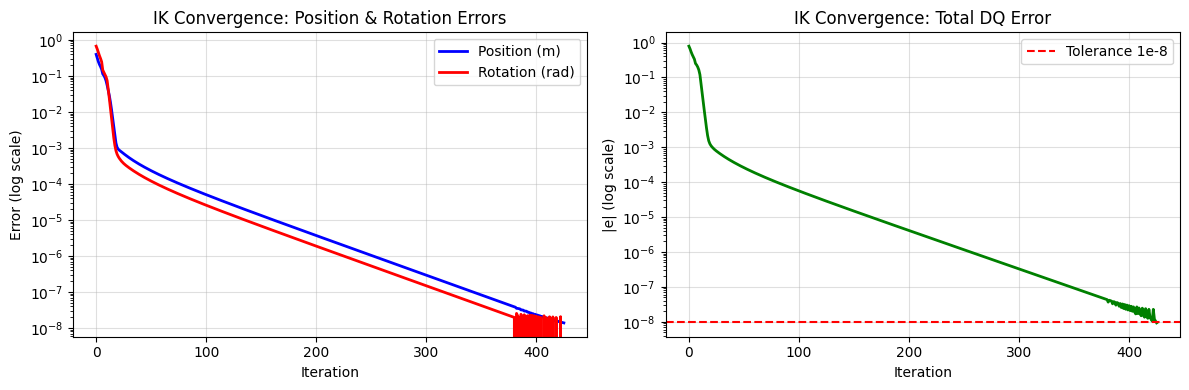


Final Results:
  Converged: True
  Position error: 0.000014 mm
  Rotation error: 0.000000 deg
  Solved joints:  [ 0.106383  0.053995  0.07848   0.10976   0.2151   -0.261886]
  True joints:    [ 0.106383  0.053996  0.078479  0.10976   0.2151   -0.261886]


In [54]:
# ============================================================
# PLOT IK CONVERGENCE HISTORY
# ============================================================

# Run one IK with verbose=True and plot convergence
theta_true = np.random.uniform(-np.pi*0.1, np.pi*0.1, 6)
#theta_true = np.array([0.5, -1.0, 0.8, -0.5, 1.2, 0.3])
Q_target   = fk_dq(S, theta_true, M_dq)
#theta_init = np.zeros(6)
theta_init = theta_true + np.random.uniform(-0.5, 0.5, 6)
theta_initf = np.clip(theta_init, UR5_Q_MIN_SAFE, UR5_Q_MAX_SAFE)

print('Running IK from all-zeros initial guess...')
theta_sol, converged, history = inverse_kinematics(
    S, M_dq, Q_target, theta_initf,
    tol=1e-8, max_iter=500, lam=0.05, alpha=0.5, verbose=True
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(history['iter'], history['pos_err'], 'b-', linewidth=2, label='Position (m)')
axes[0].semilogy(history['iter'], history['rot_err'], 'r-', linewidth=2, label='Rotation (rad)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Error (log scale)')
axes[0].set_title('IK Convergence: Position & Rotation Errors')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].semilogy(history['iter'], history['total_err'], 'g-', linewidth=2)
axes[1].axhline(y=1e-8, color='r', linestyle='--', label='Tolerance 1e-8')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('|e| (log scale)')
axes[1].set_title('IK Convergence: Total DQ Error')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# Final verification
Q_final = fk_dq(S, theta_sol, M_dq)
pos_err, rot_err = pose_error_metrics(Q_final, Q_target)
print(f'\nFinal Results:')
print(f'  Converged: {converged}')
print(f'  Position error: {pos_err*1000:.6f} mm')
print(f'  Rotation error: {np.degrees(rot_err):.6f} deg')
print(f'  Solved joints:  {theta_sol}')
print(f'  True joints:    {theta_true}')